# Stop and Search Analysis (February 2023 – January 2025)

Analysis of UK police stop and search incidents using open data. This notebook covers data loading, cleaning, and exploratory analysis across time, geography, gender, age, and ethnicity.

## 1. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 
from jinja2 import Template

# widen display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

# Consistent plot styling
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

# Load raw data
df_raw = pd.read_csv('all-stop-and-search.csv')

# Remove exact duplicate rows
df_clean = df_raw.drop_duplicates()

print(f'Raw rows:   {df_raw.shape[0]:,}')
print(f'After dedup: {df_clean.shape[0]:,}  ({df_raw.shape[0] - df_clean.shape[0]:,} duplicates removed)')


Raw rows:   43,738
After dedup: 43,081  (657 duplicates removed)


## 2. Data Inspection

In [3]:
# Schema and non-null counts
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 43081 entries, 0 to 43737
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Type                                      43081 non-null  object 
 1   Date                                      43081 non-null  object 
 2   Part of a policing operation              0 non-null      float64
 3   Policing operation                        0 non-null      float64
 4   Latitude                                  42795 non-null  float64
 5   Longitude                                 42795 non-null  float64
 6   Gender                                    40163 non-null  object 
 7   Age range                                 37875 non-null  object 
 8   Self-defined ethnicity                    43081 non-null  object 
 9   Officer-defined ethnicity                 42446 non-null  object 
 10  Legislation                            

In [4]:
df_clean.head()

,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
0,Person search,2023-02-01T00:23:00+00:00,NaN,NaN,51.541693,-0.003752,NaN,10-17,White - Any other White background,White,Police and Criminal Evidence Act 1984 (section 1),Anything to threaten or harm anyone,A no further action disposal,False,False
1,Person search,2023-02-01T01:35:00+00:00,NaN,NaN,51.399168,-0.100113,Female,18-24,White - English/Welsh/Scottish/Northern Irish/...,White,Police and Criminal Evidence Act 1984 (section 1),Anything to threaten or harm anyone,A no further action disposal,True,False
2,Person search,2023-02-01T09:53:00+00:00,NaN,NaN,51.539928,0.080288,Male,10-17,White - Any other White background,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,False,False
3,Person search,2023-02-01T11:00:00+00:00,NaN,NaN,53.208562,-2.891456,Male,25-34,White - Irish,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,True,False
4,Person search,2023-02-01T11:30:00+00:00,NaN,NaN,53.208562,-2.891456,Male,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,True,False


In [5]:
df_clean.describe(include='all')

,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
count,43081,43081,0.0,0.0,42795.000000,42795.000000,40163,37875,43081,42446,42460,42692,43046,43048,43048
unique,3,39294,NaN,NaN,NaN,NaN,3,5,17,4,7,12,7,2,2
top,Person search,2024-10-04T16:00:00+00:00,NaN,NaN,NaN,NaN,Male,18-24,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,False,False
freq,42752,7,NaN,NaN,NaN,NaN,36554,11495,17066,24106,28137,27905,36766,25762,42798
mean,NaN,NaN,NaN,NaN,52.134919,-0.836211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.107547,1.189161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,50.148324,-5.659012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,51.496420,-1.853315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,51.537779,-0.158441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,52.582328,-0.086493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Steps:
1. Drop columns that are 100% null (`Part of a policing operation`, `Policing operation`).
2. Fill remaining categorical NaNs with `'Not recorded'`.
3. Parse `Date` into a proper datetime and extract time features.
4. Standardise `Age range` values (e.g. Excel-mangled `oct-17` → `10-17`).
5. Note: 286 rows have no lat/lon — these are kept but excluded from geographic plots.

In [6]:
# 3a. Drop always-null columns
cols_all_null = [c for c in df_clean.columns if df_clean[c].isna().all()]
print('Dropping fully-null columns:', cols_all_null)
df_clean = df_clean.drop(columns=cols_all_null)

# 3b. Fill categorical NaNs
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Not recorded')

# 3c. Parse Date and engineer time features
df_clean['Date'] = pd.to_datetime(df_clean['Date'], utc=True)
df_clean['Year']      = df_clean['Date'].dt.year
df_clean['Month']     = df_clean['Date'].dt.to_period('M').astype(str)
df_clean['Hour']      = df_clean['Date'].dt.hour
df_clean['DayOfWeek'] = pd.Categorical(
    df_clean['Date'].dt.day_name(),
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)

# 3d. Standardise Age range (all kept lowercase to match .str.lower() output)
age_map = {
    'oct-17':       '10-17',
    'under 10':     'under 10',
    '10-17':        '10-17',
    '18-24':        '18-24',
    '25-34':        '25-34',
    'over 34':      'over 34',
    'not recorded': 'not recorded'
}
df_clean['Age range'] = df_clean['Age range'].str.strip().str.lower().replace(age_map)

# Working copy
df_analysis = df_clean.copy()

# Drop date column as we have extracted all relevant time featur   
df_analysis.drop(columns=['Date'], inplace=True)

# Verify remaining nulls
remaining = df_analysis.isna().sum()
print('\nRemaining NaN counts:')
print(remaining[remaining > 0])


Dropping fully-null columns: ['Part of a policing operation', 'Policing operation']


C:\Users\teres\AppData\Local\Temp\ipykernel_15900\744455742.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['Month']     = df_clean['Date'].dt.to_period('M').astype(str)



Remaining NaN counts:
Latitude     286
Longitude    286
dtype: int64


In [7]:
df_analysis.shape


(43081, 16)

In [8]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43081 entries, 0 to 43737
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   Type                                      43081 non-null  object  
 1   Latitude                                  42795 non-null  float64 
 2   Longitude                                 42795 non-null  float64 
 3   Gender                                    43081 non-null  object  
 4   Age range                                 43081 non-null  object  
 5   Self-defined ethnicity                    43081 non-null  object  
 6   Officer-defined ethnicity                 43081 non-null  object  
 7   Legislation                               43081 non-null  object  
 8   Object of search                          43081 non-null  object  
 9   Outcome                                   43081 non-null  object  
 10  Outcome linked to object of

### Save to a CSV data file for later use in Power BI 

In [9]:
df_analysis.to_csv("df_analysis_clean.csv", index=False)

## 4. Temporal Patterns

### 4.1 By Month

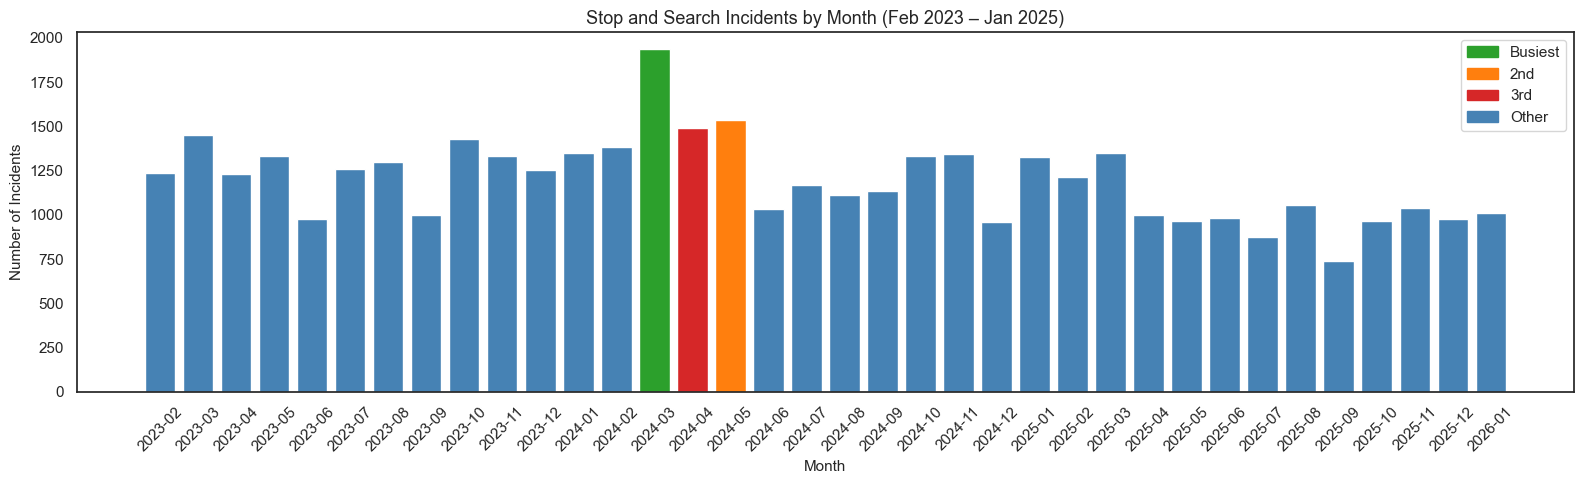

In [10]:
month_counts = df_analysis['Month'].value_counts().sort_index()
top3 = month_counts.nlargest(3).index

colors = []
for m in month_counts.index:
    if m == top3[0]:   colors.append('#2ca02c')    # busiest
    elif m == top3[1]: colors.append('#ff7f0e')    # 2nd
    elif m == top3[2]: colors.append('#d62728')    # 3rd
    else:              colors.append('steelblue')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(month_counts.index, month_counts.values, color=colors)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Incidents')
ax.set_title('Stop and Search Incidents by Month (Feb 2023 – Jan 2025)')
ax.tick_params(axis='x', rotation=45)
# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#2ca02c', label='Busiest'), Patch(color='#ff7f0e', label='2nd'),
          Patch(color='#d62728', label='3rd'), Patch(color='steelblue', label='Other')]
ax.legend(handles=legend, loc='upper right')
plt.tight_layout()
plt.show()


### 4.2 By Year

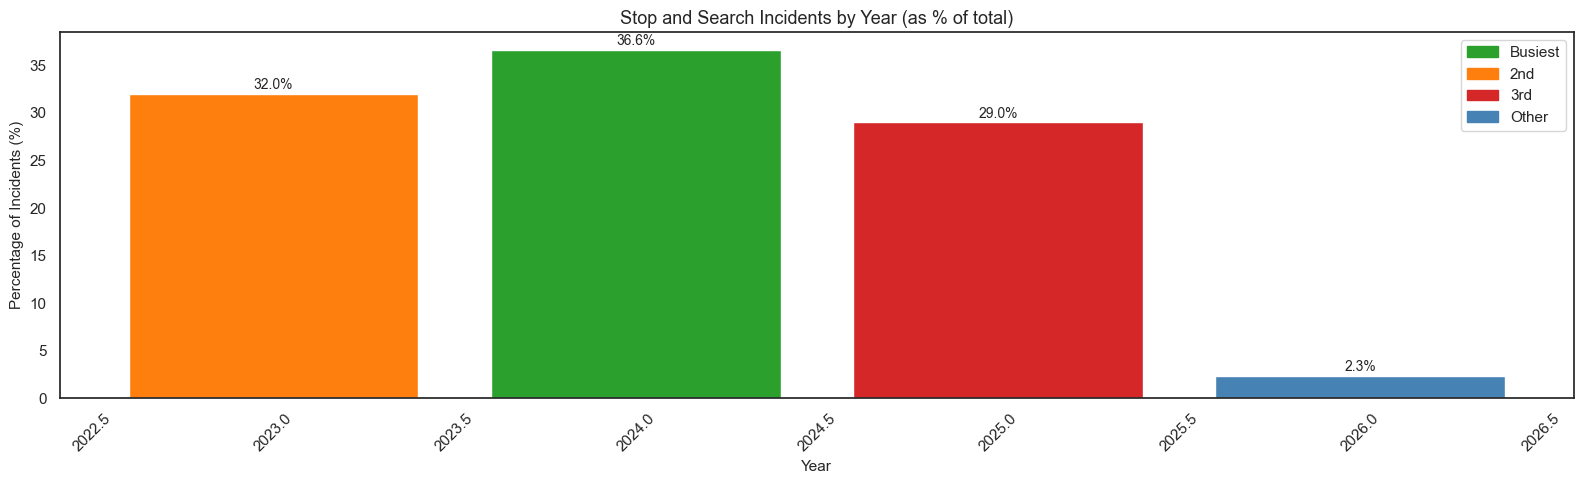

In [11]:
from matplotlib.patches import Patch

# --- 1. Year counts and percentages ---
year_counts = df_analysis['Year'].value_counts().sort_index()
year_pct = (year_counts / year_counts.sum()) * 100

# --- 2. Identify top 3 busiest years ---
top3 = year_pct.nlargest(3).index

# --- 3. Build colour list ---
colors = []
for y in year_pct.index:
    if y == top3[0]:
        colors.append('#2ca02c')    # busiest
    elif y == top3[1]:
        colors.append('#ff7f0e')    # 2nd
    elif y == top3[2]:
        colors.append('#d62728')    # 3rd
    else:
        colors.append('steelblue')

# --- 4. Plot ---
year_pct.index = year_pct.index.astype(int)   # ← force integer years

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(year_pct.index, year_pct.values, color=colors)


ax.set_xlabel('Year')
ax.set_ylabel('Percentage of Incidents (%)')
ax.set_title('Stop and Search Incidents by Year (as % of total)')
ax.tick_params(axis='x', rotation=45)

# --- 5. Add % labels above bars ---
for i, v in enumerate(year_pct.values):
    ax.text(year_pct.index[i], v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

# --- 6. Legend ---
legend = [
    Patch(color='#2ca02c', label='Busiest'),
    Patch(color='#ff7f0e', label='2nd'),
    Patch(color='#d62728', label='3rd'),
    Patch(color='steelblue', label='Other')
]
ax.legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.show()



### 4.3 By Day of Week

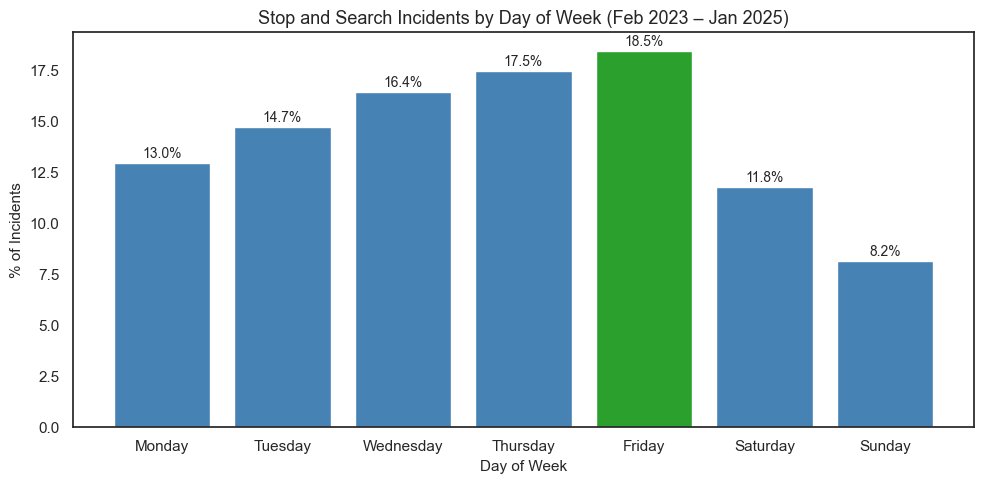

In [12]:
day_counts = df_analysis['DayOfWeek'].value_counts().sort_index()
day_percent = day_counts / day_counts.sum() * 100
top_day = day_counts.idxmax()
colors = ['#2ca02c' if d == top_day else 'steelblue' for d in day_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_counts.index, day_percent.values, color=colors)
for bar, val in zip(bars, day_percent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Day of Week')
ax.set_ylabel('% of Incidents')
ax.set_title('Stop and Search Incidents by Day of Week (Feb 2023 – Jan 2025)')
plt.tight_layout()
plt.show()


### 4.4 By Hour of Day

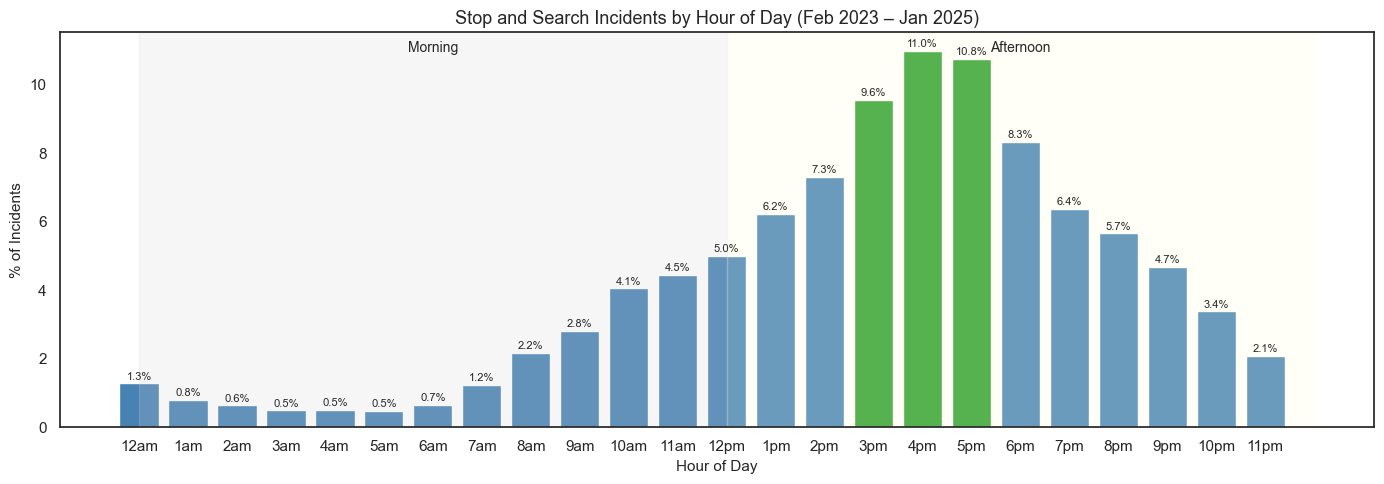

In [13]:
# convert 24 hors to am/pm
def hour_to_label(h):
    if h == 0:
        return "12am"
    elif 1 <= h < 12:
        return f"{h}am"
    elif h == 12:
        return "12pm"
    else:
        return f"{h-12}pm"

# Add tidy label column
df_analysis['HourLabel'] = df_analysis['Hour'].apply(hour_to_label)

hour_counts = df_analysis['Hour'].value_counts().sort_index()
hour_percent = hour_counts / hour_counts.sum() * 100
top3_hours = hour_counts.nlargest(3).index
colors = ['#2ca02c' if h in top3_hours else 'steelblue' for h in hour_counts.index]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(hour_counts.index, hour_percent.values, color=colors)

for bar, val in zip(bars, hour_percent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(hour_counts.index)
ax.set_xticklabels([hour_to_label(h) for h in hour_counts.index])

ax.set_xlabel('Hour of Day')
ax.set_ylabel('% of Incidents')
ax.set_title('Stop and Search Incidents by Hour of Day (Feb 2023 – Jan 2025)')

# Morning shading (0–11)
ax.axvspan(0, 12, color='lightgrey', alpha=0.2)

# Afternoon shading (12–24)
ax.axvspan(12, 24, color='lightyellow', alpha=0.2)

ax.text(6, ax.get_ylim()[1] * 0.95, "Morning", ha='center', fontsize=10)
ax.text(18, ax.get_ylim()[1] * 0.95, "Afternoon", ha='center', fontsize=10)


plt.tight_layout()
plt.show()




## 5. Geographic Distribution

Plotting 42,795 incidents with known coordinates 
(286 excluded due to missing coordinates)


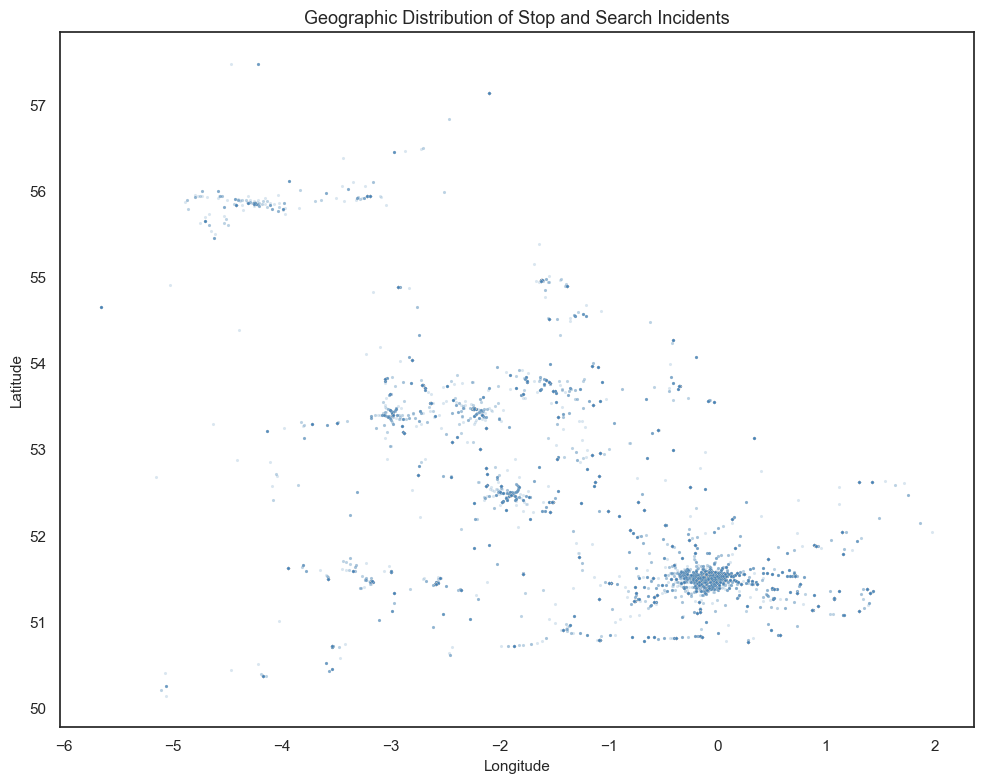

In [14]:
# Exclude rows without coordinates
df_geo = df_analysis.dropna(subset=['Latitude', 'Longitude'])
print(f'Plotting {len(df_geo):,} incidents with known coordinates ')
print(f'({len(df_analysis) - len(df_geo):,} excluded due to missing coordinates)')

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df_geo, x='Longitude', y='Latitude',
                alpha=0.2, s=5, color='steelblue', ax=ax)
ax.set_title('Geographic Distribution of Stop and Search Incidents')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


## 6. Demographics

### 6.1 Gender

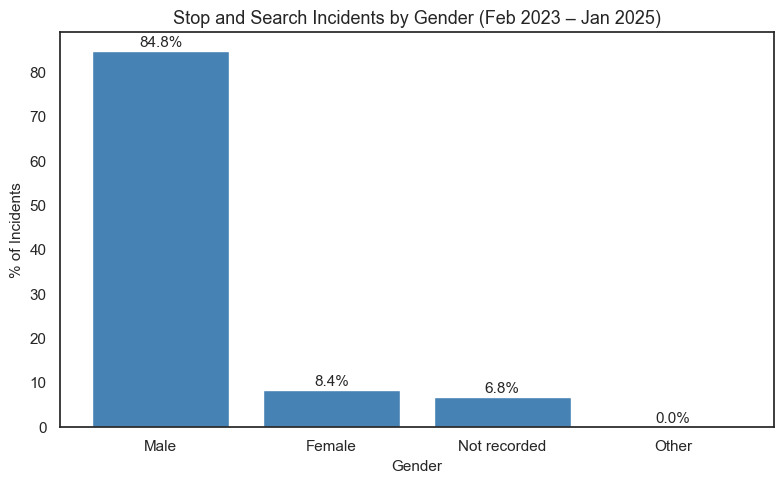

In [15]:
gender_counts = df_analysis['Gender'].value_counts()
gender_percent = gender_counts / gender_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(gender_counts.index, gender_percent.values, color='steelblue')
for bar, val in zip(bars, gender_percent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Gender')
ax.set_ylabel('% of Incidents')
ax.set_title('Stop and Search Incidents by Gender (Feb 2023 – Jan 2025)')
plt.tight_layout()
plt.show()


### 6.2 Age Group

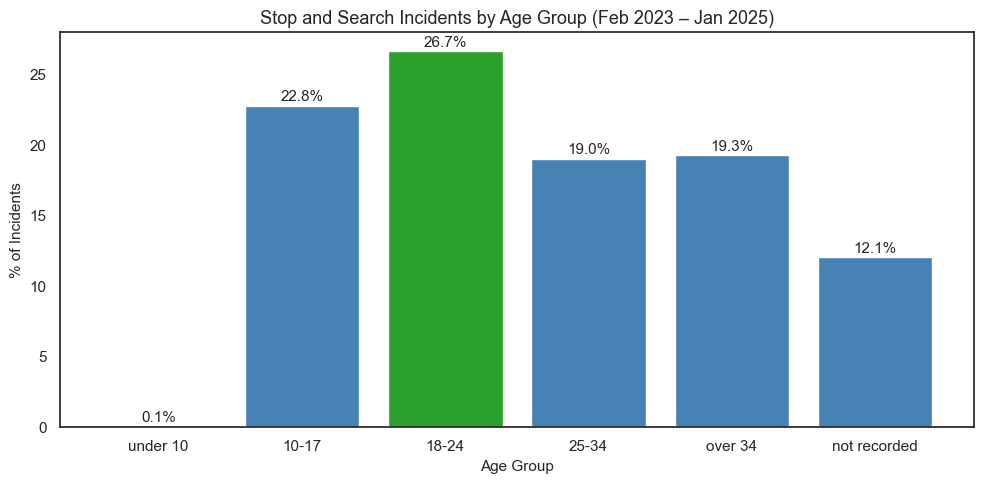

In [16]:
age_order = ['under 10', '10-17', '18-24', '25-34', 'over 34', 'not recorded']
age_counts = df_analysis['Age range'].value_counts().reindex(age_order, fill_value=0)
age_percent = age_counts / age_counts.sum() * 100
top_age = age_counts.idxmax()
colors = ['#2ca02c' if a == top_age else 'steelblue' for a in age_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_counts.index, age_percent.values, color=colors)
for bar, val in zip(bars, age_percent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Age Group')
ax.set_ylabel('% of Incidents')
ax.set_title('Stop and Search Incidents by Age Group (Feb 2023 – Jan 2025)')
plt.tight_layout()
plt.show()


### 6.3 Ethnicity

### 6.3.1 Officer defined ethnicity

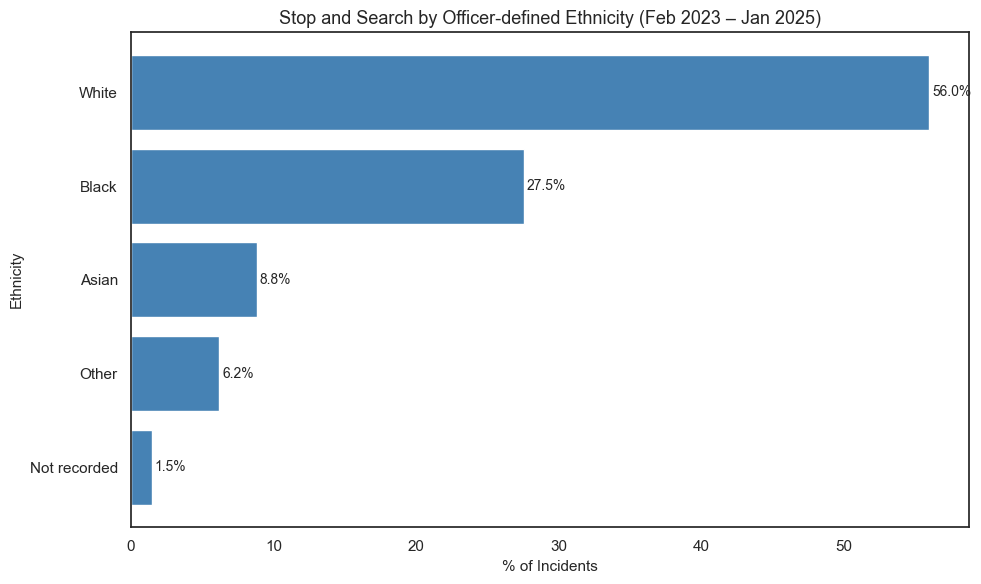

In [17]:
counts = df_analysis['Officer-defined ethnicity'].value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Ethnicity')
ax.set_title('Stop and Search by Officer-defined Ethnicity (Feb 2023 – Jan 2025)')
plt.tight_layout()
plt.show()

### 6.3.2 Self-defined ethnicity

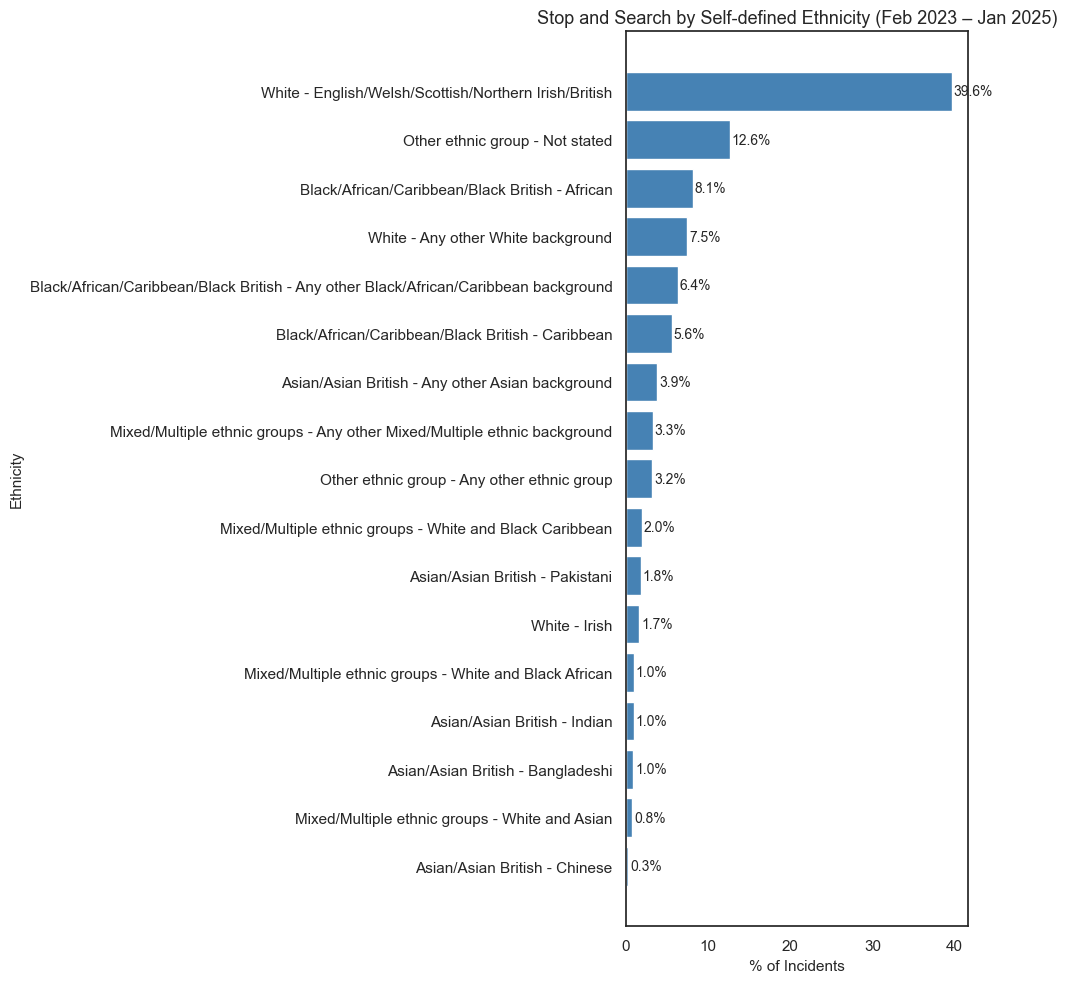

In [18]:
# Self-defined ethnicity
counts = df_analysis['Self-defined ethnicity'].value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(counts.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Ethnicity')
ax.set_title('Stop and Search by Self-defined Ethnicity (Feb 2023 – Jan 2025)')
plt.tight_layout()
plt.show()

## 7. Legislation


### 7.1 Legislation

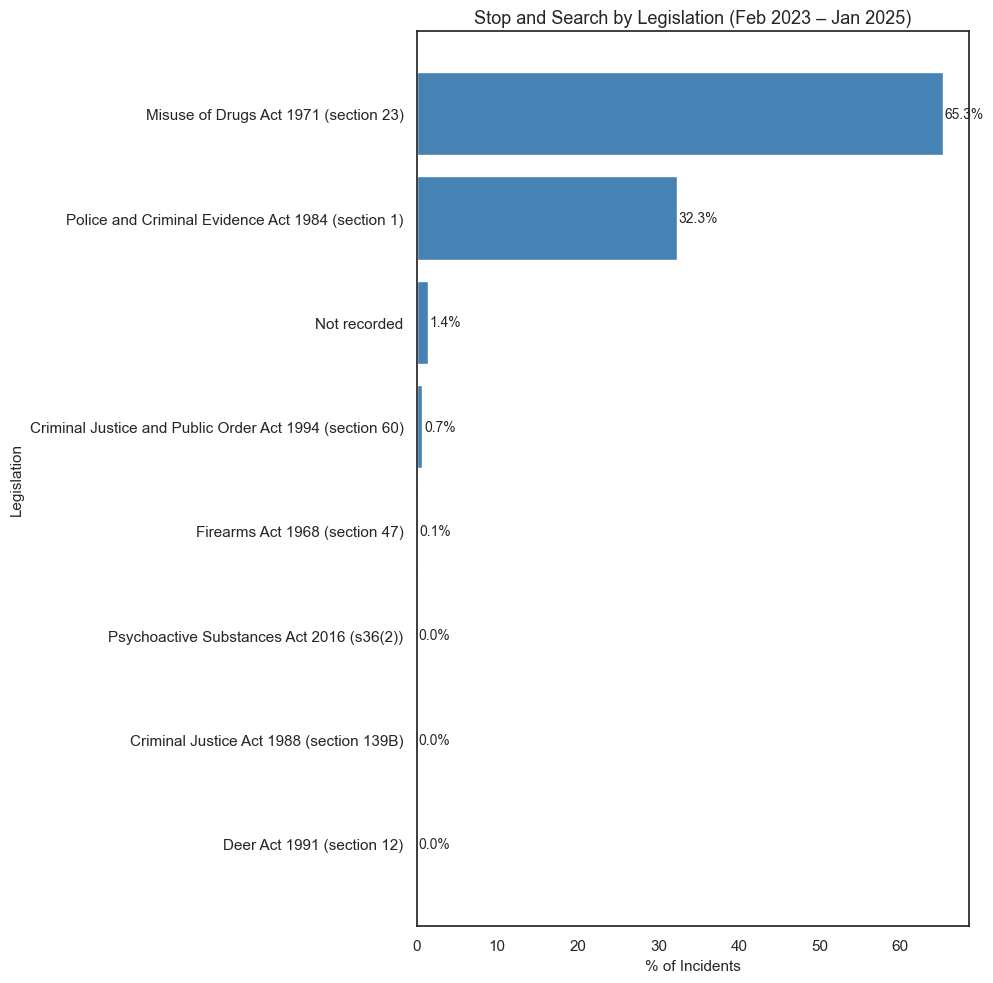

In [19]:
# Legislation
counts = df_analysis['Legislation'].value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100   
fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(counts.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Legislation')
ax.set_title('Stop and Search by Legislation (Feb 2023 – Jan 2025)')
plt.tight_layout()  

### 7.2 Object of Search

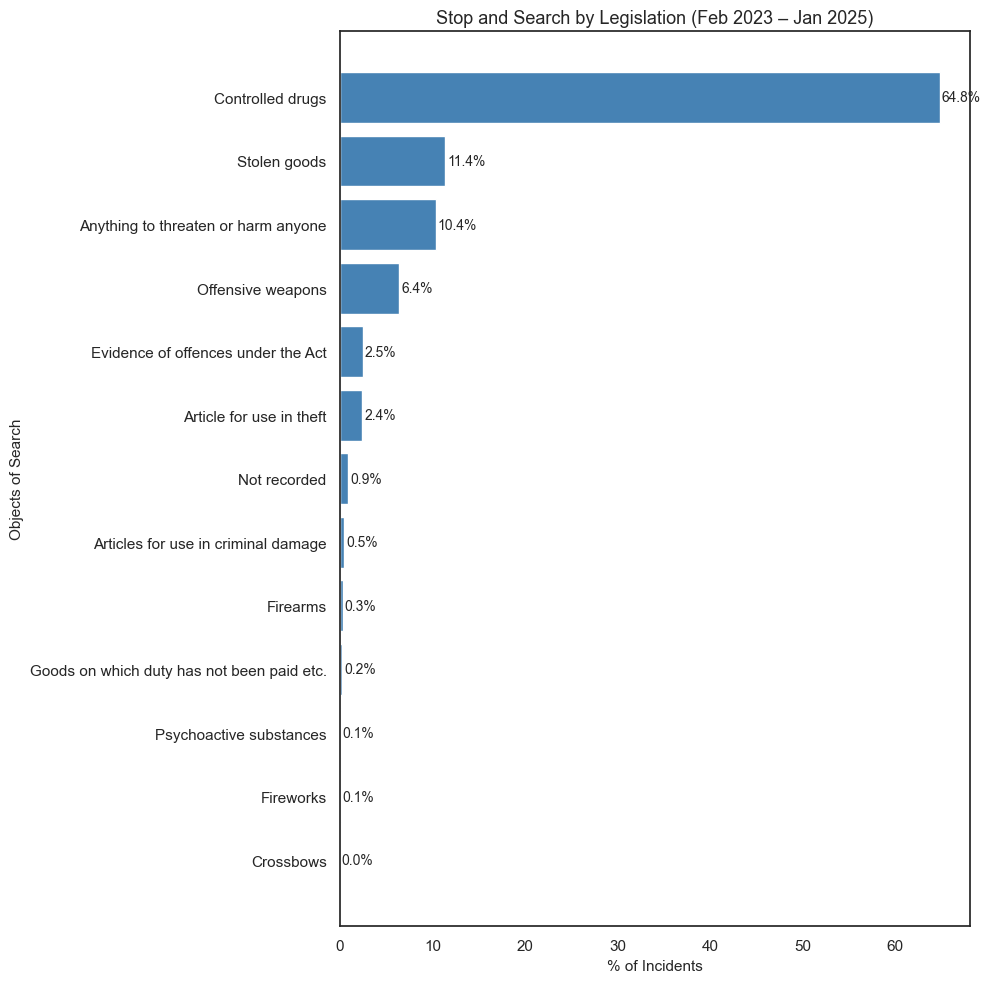

In [20]:
counts = df_analysis['Object of search'].value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100   
fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(counts.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Objects of Search')
ax.set_title('Stop and Search by Legislation (Feb 2023 – Jan 2025)')
plt.tight_layout() 

### 7.3 Outcome

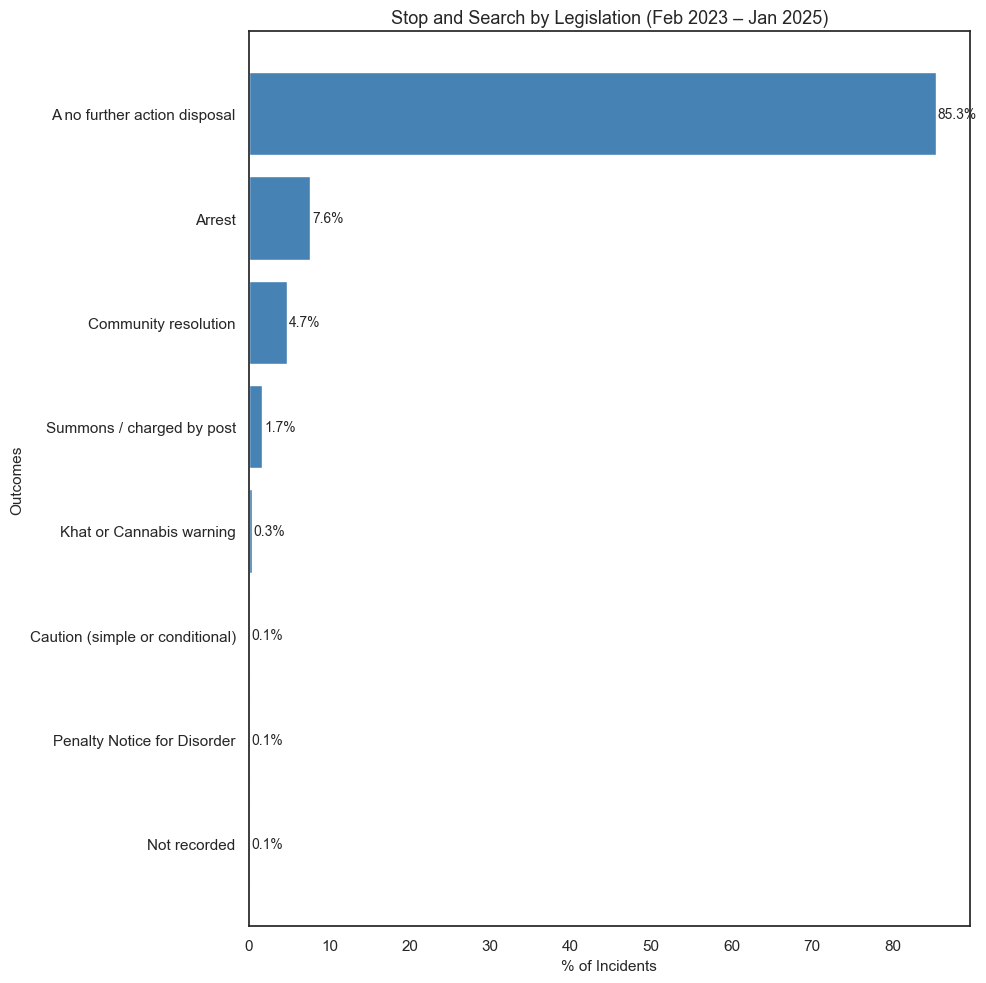

In [21]:
counts = df_analysis['Outcome'].value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100   
fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(counts.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Outcomes')
ax.set_title('Stop and Search by Legislation (Feb 2023 – Jan 2025)')
plt.tight_layout() 

### 7.4 Outcome linked to object of search - Boolean

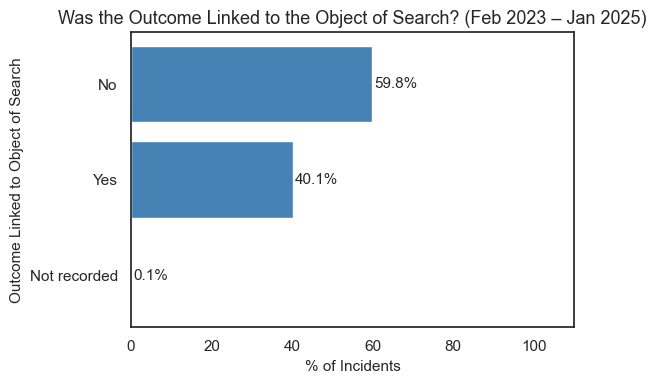

In [22]:
counts = df_analysis['Outcome linked to object of search'].astype(str).value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100

# Rename directly without map
pct.index = ['Not recorded', 'Yes', 'No']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(pct.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=11)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Outcome Linked to Object of Search')
ax.set_title('Was the Outcome Linked to the Object of Search? (Feb 2023 – Jan 2025)')
ax.set_facecolor('white')
ax.grid(False)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()


### 7.5 Outcome linked to removal of more than jsut outer clothing?

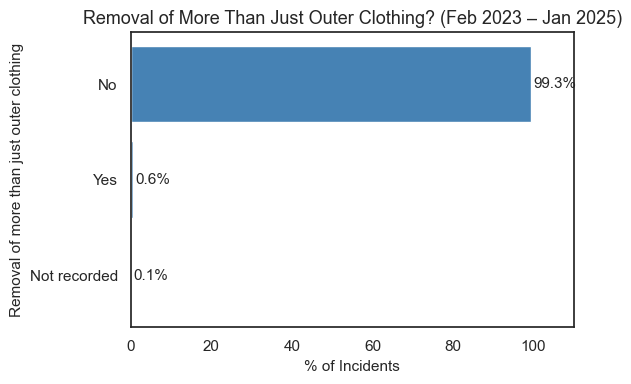

In [23]:
counts = df_analysis['Removal of more than just outer clothing'].astype(str).value_counts().sort_values(ascending=True)
pct = counts / counts.sum() * 100

# Rename directly without map
pct.index = ['Not recorded', 'Yes', 'No']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(pct.index, pct.values, color='steelblue')
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=11)
ax.set_xlabel('% of Incidents')
ax.set_ylabel('Removal of more than just outer clothing')
ax.set_title('Removal of More Than Just Outer Clothing? (Feb 2023 – Jan 2025)')
ax.set_facecolor('white')
ax.grid(False)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()


## 8. Cross-tabulations and relationships between variables

Row-normalised percentages show the age distribution *within* each gender.

In [ ]:

age_order = ['under 10', '10-17', '18-24', '25-34', 'over 34', 'not recorded']

# Row‑normalised % table
ct = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Age range'],
    normalize='index'
) * 100

ct = ct.reindex(columns=age_order)

# Raw counts table (needed for totals)
gender_age_counts = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Age range']
)

# Insert total counts as first column
ct.insert(0, 'Total', gender_age_counts.sum(axis=1))


# --- Column-wise min/max highlighter ---
def highlight_col_minmax(s):
    if s.name == "Total":   # skip Total column entirely
        return [""] * len(s)

    is_max = s == s.max()
    is_min = s == s.min()

    return [
        "background-color: lightgreen; color: black" if is_max.iloc[i] else
        "background-color: #f5b5b5; color: black" if is_min.iloc[i] else
        ""
        for i in range(len(s))
    ]


# Apply column-wise highlighting to all non-Total columns
cols_to_highlight = [c for c in ct.columns if c != "Total"]

styled_ct = ct.style.apply(
    highlight_col_minmax,
    axis=0,
    subset=cols_to_highlight
)

styled_ct


# Row high and low %

Age range,Total,under 10,10-17,18-24,25-34,over 34,not recorded
Gender,,,,,,,
Female,3598,0.138966,21.789883,23.346304,18.593663,23.957754,12.173430
Male,36554,0.065656,22.213711,26.566176,19.204465,19.100509,12.849483
Not recorded,2918,0.000000,31.391364,32.248115,17.649075,16.346813,2.364633
Other,11,0.000000,36.363636,27.272727,9.090909,9.090909,18.181818


In [314]:
age_order = ['under 10', '10-17', '18-24', '25-34', 'over 34', 'not recorded']

# Row‑normalised % table
ct = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Age range'],
    normalize='index'
) * 100

ct = ct.reindex(columns=age_order)

# Raw counts table (needed for totals)
gender_age_counts = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Age range']
)

# Insert total counts as first column
ct.insert(0, 'Total', gender_age_counts.sum(axis=1))


# --- Column-wise min/max highlighter ---
def highlight_col_minmax(s):
    if s.name == "Total":   # skip Total column entirely
        return [""] * len(s)

    is_max = s == s.max()
    is_min = s == s.min()

    return [
        "background-color: lightgreen; color: black" if is_max.iloc[i] else
        "background-color: #f5b5b5; color: black" if is_min.iloc[i] else
        ""
        for i in range(len(s))
    ]


# Apply to all columns except Total
cols_to_highlight = [c for c in ct.columns if c != "Total"]

styled_ct = ct.style.apply(
    highlight_col_minmax,
    axis=0,
    subset=cols_to_highlight
)

styled_ct


Age range,Total,under 10,10-17,18-24,25-34,over 34,not recorded
Gender,,,,,,,
Female,3598,0.138966,21.789883,23.346304,18.593663,23.957754,12.173430
Male,36554,0.065656,22.213711,26.566176,19.204465,19.100509,12.849483
Not recorded,2918,0.000000,31.391364,32.248115,17.649075,16.346813,2.364633
Other,11,0.000000,36.363636,27.272727,9.090909,9.090909,18.181818


Does outcome vary by ethnicity? (e.g. are certain groups more likely to get "no further action"?)

In [315]:
# Outcome by ethnicity (row-normalised %)
ct = pd.crosstab(
    df_analysis['Outcome'],
    df_analysis['Officer-defined ethnicity'],
    normalize='index'
) * 100

# Reorder ethnicity columns sensibly
ethnicity_order = ['White', 'Black', 'Asian', 'Other', 'Not recorded']
ct = ct.reindex(columns=[c for c in ethnicity_order if c in ct.columns])
ct.round(1)
print(ct.round(1))



Officer-defined ethnicity        White  Black  Asian  Other  Not recorded
Outcome                                                                  
A no further action disposal      56.0   27.6    8.9    6.1           1.4
Arrest                            52.4   29.9    7.8    8.5           1.4
Caution (simple or conditional)   76.6   12.8   10.6    0.0           0.0
Community resolution              58.9   24.8   10.0    5.2           1.1
Khat or Cannabis warning          49.0   28.0   14.7    7.0           1.4
Not recorded                      14.3    8.6    2.9    2.9          71.4
Penalty Notice for Disorder       56.4   28.2   12.8    0.0           2.6
Summons / charged by post         62.8   22.1    7.7    4.8           2.6


Does object of search vary by age or gender?

In [316]:
# Outcome by Gender and Age range (row-normalised %)
ct = pd.crosstab(
    df_analysis['Outcome'],
    [df_analysis['Gender'], df_analysis['Age range']],
    normalize='index'
) * 100

# Reorder columns
age_order = ['under 10', '10-17', '18-24', '25-34', 'over 34', 'not recorded']
gender_order = ['Male', 'Female', 'Not recorded', 'Other']

# Reindex with MultiIndex
new_cols = [(g, a) for g in gender_order for a in age_order 
            if (g, a) in ct.columns]
ct = ct.reindex(columns=new_cols)
ct.round(1)

Gender                              Male                                          Female                                        Not recorded                                  Other                                 
Age range                       under 10 10-17 18-24 25-34 over 34 not recorded under 10 10-17 18-24 25-34 over 34 not recorded        10-17 18-24 25-34 over 34 not recorded 10-17 18-24 25-34 over 34 not recorded
Outcome                                                                                                                                                                                                             
A no further action disposal         0.1  19.8  21.5  15.4    15.5         12.5      0.0   2.0   1.9   1.5     1.9          1.2          2.2   2.1   1.1     1.0          0.1   0.0   0.0   0.0     0.0          0.0
Arrest                               0.1  20.1  22.3  19.8    21.3          1.9      0.0   1.3   1.0   1.3     2.6          0.1          2.7   2.5   1.4     1.5          0.1   0.0   0.0   0.0     0.0          0.0
Caution (simple or conditional)      0.0  12.8  23.4  27.7    14.9          2.1      0.0   2.1   2.1   0.0     8.5          0.0          0.0   4.3   2.1     0.0          0.0   0.0   0.0   0.0     0.0          0.0
Community resolution                 0.0   2.9  38.2  25.2    18.1          1.1      0.0   0.3   3.8   2.0     2.2          0.1          0.4   2.6   1.7     1.1          0.2   0.0   0.1   0.0     0.0          0.0
Khat or Cannabis warning             0.0  11.2  35.0  21.7    15.4          4.9      0.0   0.7   4.9   0.7     0.0          0.0          2.1   2.8   0.7     0.0          0.0   0.0   0.0   0.0     0.0          0.0
Not recorded                         0.0   5.7   8.6  14.3     2.9          5.7      0.0   0.0   0.0   0.0     0.0          0.0         11.4  11.4  11.4     5.7         22.9   0.0   0.0   0.0     0.0          0.0
Penalty Notice for Disorder          0.0  12.8  28.2  17.9    20.5          2.6      0.0   2.6   2.6   2.6     5.1          0.0          0.0   2.6   0.0     2.6          0.0   0.0   0.0   0.0     0.0          0.0
Summons / charged by post            0.0  11.9  30.7  20.4    21.8          0.7      0.1   0.5   0.8   2.2     3.2          0.0          1.2   2.2   1.6     2.3          0.1   0.0   0.0   0.0     0.0          0.0

Are certain legislation types used more on specific ethnic group types?

Time trends: Has the nuumber of searches increaed or decread over the 2 years 

Do certain ethnic groups get searched more at particular times of day or days of week?

### Do differnt ages have differnt search profiles? Exclude under 10 from analysis

In [332]:
df_analysis['Age range'].value_counts()

Age range
18-24           11495
10-17            9824
over 34          8322
25-34            8205
not recorded     5206
under 10           29
Name: count, dtype: int64

In [333]:
# Checking class imbalance
# Feature Scaling
# Interpreting coefficient for multiples


In [334]:
age_order = [
    'under 10',
    '10-17',
    '18-24',
    '25-34',
    'over 34',
    'not recorded'
]
df_analysis['Age range'] = pd.Categorical(
    df_analysis['Age range'],
    categories=age_order,
    ordered=True
)
age_object_counts = pd.crosstab(
    df_analysis['Age range'],
    df_analysis['Object of search']
).loc[age_order]

print("Age × Object of Search — Counts (Ordered)")
display(age_object_counts)





Age × Object of Search — Counts (Ordered)


Object of search,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Age range,,,,,,,,,,,,,
under 10,1,1,1,23,0,0,0,0,0,0,0,0,3
10-17,1738,307,104,5085,0,310,42,15,19,100,1215,11,878
18-24,1051,180,44,8433,1,227,20,9,6,74,695,14,741
25-34,463,197,22,5832,0,174,15,5,20,65,254,11,1147
over 34,558,251,24,5148,1,217,43,3,51,85,246,8,1687
not recorded,657,113,16,3384,0,134,20,2,7,65,358,3,447


In [335]:
age_object_pct_rows = pd.crosstab(
    df_analysis['Age range'],
    df_analysis['Object of search'],
    normalize='index'
).round(3).loc[age_order]

# Add total count column on the left
age_object_pct_rows.insert(0, 'Total', age_object_counts.sum(axis=1))

age_object_pct_rows



Object of search,Total,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Age range,,,,,,,,,,,,,,
under 10,29,0.034,0.034,0.034,0.793,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.103
10-17,9824,0.177,0.031,0.011,0.518,0.0,0.032,0.004,0.002,0.002,0.010,0.124,0.001,0.089
18-24,11495,0.091,0.016,0.004,0.734,0.0,0.020,0.002,0.001,0.001,0.006,0.060,0.001,0.064
25-34,8205,0.056,0.024,0.003,0.711,0.0,0.021,0.002,0.001,0.002,0.008,0.031,0.001,0.140
over 34,8322,0.067,0.030,0.003,0.619,0.0,0.026,0.005,0.000,0.006,0.010,0.030,0.001,0.203
not recorded,5206,0.126,0.022,0.003,0.650,0.0,0.026,0.004,0.000,0.001,0.012,0.069,0.001,0.086


In [336]:
# Highlights the top and bottom % in each column
def highlight_min_max(s):
    is_max = s == s.max()
    is_min = s == s.min()

    return [
        "background-color: #b6e3b6; color: black" if is_max.iloc[i] else
        "background-color: #f5b5b5; color: black" if is_min.iloc[i] else
        ""
        for i in range(len(s))
    ]



# Apply styling (skip the 'Total' column)
cols_to_highlight = [
    c for c in age_object_pct_rows.columns
    if c not in ["Total", "Crossbows"]
]

styled_age_object_rows = (
    age_object_pct_rows.style
        .apply(
            highlight_min_max,
            subset=cols_to_highlight,
            axis=0
        )
        .format("{:.3f}")
)

styled_age_object_rows




Object of search,Total,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Age range,,,,,,,,,,,,,,
under 10,29.000,0.034,0.034,0.034,0.793,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.103
10-17,9824.000,0.177,0.031,0.011,0.518,0.000,0.032,0.004,0.002,0.002,0.010,0.124,0.001,0.089
18-24,11495.000,0.091,0.016,0.004,0.734,0.000,0.020,0.002,0.001,0.001,0.006,0.060,0.001,0.064
25-34,8205.000,0.056,0.024,0.003,0.711,0.000,0.021,0.002,0.001,0.002,0.008,0.031,0.001,0.140
over 34,8322.000,0.067,0.030,0.003,0.619,0.000,0.026,0.005,0.000,0.006,0.010,0.030,0.001,0.203
not recorded,5206.000,0.126,0.022,0.003,0.650,0.000,0.026,0.004,0.000,0.001,0.012,0.069,0.001,0.086


### Build the equivalent gender table

In [337]:

# get the gender counts 
gender_order = ["Male", "Female", "Not recorded", "Other"]

gender_object_counts = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Object of search']
).loc[gender_order]

gender_object_counts





Object of search,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Gender,,,,,,,,,,,,,
Male,3813,937,185,23849,1,833,122,30,77,300,2482,38,3887
Female,333,45,12,2226,0,167,9,1,20,51,71,3,660
Not recorded,320,67,14,1822,1,62,9,3,6,38,215,6,355
Other,2,0,0,8,0,0,0,0,0,0,0,0,1


In [338]:
# Row-normalised percentage table
gender_object_pct_rows = pd.crosstab(
    df_analysis['Gender'],
    df_analysis['Object of search'],
    normalize='index'
).round(3).loc[gender_order]

# Add total count column on the left
gender_object_pct_rows.insert(0, 'Total', gender_object_counts.sum(axis=1))

gender_object_pct_rows



Object of search,Total,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Gender,,,,,,,,,,,,,,
Male,36554,0.104,0.026,0.005,0.652,0.0,0.023,0.003,0.001,0.002,0.008,0.068,0.001,0.106
Female,3598,0.093,0.013,0.003,0.619,0.0,0.046,0.003,0.000,0.006,0.014,0.020,0.001,0.183
Not recorded,2918,0.110,0.023,0.005,0.624,0.0,0.021,0.003,0.001,0.002,0.013,0.074,0.002,0.122
Other,11,0.182,0.000,0.000,0.727,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.091


In [339]:
# Column-normalised percentage table

# Highlights the top and bottom % in each column
def highlight_min_max(s):
    is_max = s == s.max()
    is_min = s == s.min()

    return [
        "background-color: #b6e3b6; color: black" if is_max.iloc[i] else
        "background-color: #f5b5b5; color: black" if is_min.iloc[i] else
        ""
        for i in range(len(s))
    ]


# Columns to highlight (skip Total + Crossbows)
cols_to_highlight_gender = [
    c for c in gender_object_pct_rows.columns
    if c not in ["Total", "Crossbows"]
]

# Apply styling
styled_gender_object_rows = (
    gender_object_pct_rows.style
        .apply(
            highlight_min_max,
            subset=cols_to_highlight_gender,
            axis=0
        )
        .format("{:.3f}")
)

styled_gender_object_rows


Object of search,Total,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
Gender,,,,,,,,,,,,,,
Male,36554.000,0.104,0.026,0.005,0.652,0.000,0.023,0.003,0.001,0.002,0.008,0.068,0.001,0.106
Female,3598.000,0.093,0.013,0.003,0.619,0.000,0.046,0.003,0.000,0.006,0.014,0.020,0.001,0.183
Not recorded,2918.000,0.110,0.023,0.005,0.624,0.000,0.021,0.003,0.001,0.002,0.013,0.074,0.002,0.122
Other,11.000,0.182,0.000,0.000,0.727,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.091


---
## 9. Statistical Testing

Chi-square tests, effect sizes (Cramér's V), and relative risk analysis to assess whether observed patterns are statistically significant.

Chi Square: To check if relationships eg ethnicity vs outomce are statistically significant?

### Chi Square: Observed Counts vs expected counts during day - Hypothesis -(one-tailed/directional)

# Null hypothesis : Incidents are equally likely in every hour
# Alternative hypothesis: Incidents are more likely to during the early to late evening than would be expected by chance

In [319]:
from scipy.stats import chisquare

# Define evening window
evening_hours = list(range(15, 22))  # 15–21 inclusive

# Observed counts
observed_in_window = hour_counts.loc[evening_hours].sum()
observed_outside = hour_counts.sum() - observed_in_window

observed = [observed_in_window, observed_outside]

# Expected counts (uniform distribution)
expected_in_window = hour_counts.sum() * (len(evening_hours) / 24)
expected_outside = hour_counts.sum() - expected_in_window

expected = [expected_in_window, expected_outside]

chi2, p_two_tailed = chisquare(f_obs=observed, f_exp=expected)

# Convert to one-tailed p-value
p_one_tailed = p_two_tailed / 2

print("Observed:", observed)
print("Expected:", expected)
print("Chi-square:", chi2)
print("Two-tailed p:", p_two_tailed)
print("One-tailed p:", p_one_tailed)

# Results: a chi-square of 10 is considered strong - this is 15413, so very strong evidence of non-uniform distribution across hours. 
# The one-tailed p-value is effectively zero, confirming that the evening window has a significantly higher proportion of incidents 
# than expected under uniform distribution.
# observed incidents = 24,278; expected: 12,565

Observed: [24278, 18803]
Expected: [12565.291666666668, 30515.708333333332]
Chi-square: 15413.611339710085
Two-tailed p: 0.0
One-tailed p: 0.0


### Effect size: Cramers V - how strong the chi-square effect is

Evening (3pm-9pm) vs Non Evening (0-2pm, 10pm-11pm)

Result: large/very large impact - evening represents 7 hours (29% of the day) but 56% of the incidents
Conclusion: Afternoon/evening spike is real, large, and meaningful

In [320]:
chi2 = 15413.611339710085
n = hour_counts.sum()

cramers_v = np.sqrt(chi2 / n)
print("Cramér's V:", cramers_v)


Cramér's V: 0.5981489078877354


# Lets split the day up into e.g. 3 hour segments to support policing iniatives

In [321]:
# 1. Define 3-hour bins and labels
bins = list(range(0, 25, 3))  # [0, 3, 6, ..., 24]
labels = [
    "00–03", "03–06", "06–09", "09–12",
    "12–15", "15–18", "18–21", "21–24"
]

# 2. Create a binned column from your Hour variable
df_analysis['HourBin'] = pd.cut(
    df_analysis['Hour'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# 3. Get counts per 3-hour bin
bin_counts = df_analysis['HourBin'].value_counts().sort_index()

print(bin_counts)

# 4. Chi-square on 3-hour bins
from scipy.stats import chisquare

observed = bin_counts.values
expected = [bin_counts.sum() / len(bin_counts)] * len(bin_counts)

chi2, p = chisquare(observed, expected)

print("Chi-square:", chi2)
print("p-value:", p)
   


HourBin
00–03     1172
03–06      641
06–09     1755
09–12     4877
12–15     7995
15–18    13488
18–21     8774
21–24     4379
Name: count, dtype: int64
Chi-square: 25748.3224391263
p-value: 0.0


In [322]:
# 4. Chi-square on 3-hour bins
from scipy.stats import chisquare

observed = bin_counts.values
expected = [bin_counts.sum() / len(bin_counts)] * len(bin_counts)

chi2, p = chisquare(observed, expected)

print("Chi-square:", chi2)
print("p-value:", p)


# Results: this chi-square is 25748, so very strong evidence of non-uniform distribution across hours. 
 

Chi-square: 25748.3224391263
p-value: 0.0


### Effect size: Cramers V - how strong the chi-square effect is

In [323]:
chi2 = 25748.3224391263
n = bin_counts.sum()

cramers_v = np.sqrt(chi2 / n)
print("Cramér's V:", cramers_v)


Cramér's V: 0.7730927165267754


# Undestanding what was the reason for the search by the 3 hour bins

In [324]:
# counts by 3 hour bins
df_analysis.groupby(['HourBin', 'Object of search']).size().unstack(fill_value=0)


C:\Users\teres\AppData\Local\Temp\ipykernel_15900\1543361403.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis.groupby(['HourBin', 'Object of search']).size().unstack(fill_value=0)


Object of search,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
HourBin,,,,,,,,,,,,,
00–03,189,51,18,658,1,32,7,2,1,12,73,2,126
03–06,98,45,24,277,0,27,2,0,1,5,43,1,118
06–09,168,76,6,955,0,64,11,0,11,32,85,2,345
09–12,275,70,7,3600,0,116,4,3,23,38,167,3,571
12–15,670,160,32,5539,0,185,18,9,13,74,438,13,844
15–18,1375,323,44,8768,1,307,41,7,21,136,1043,10,1412
18–21,1045,193,51,5566,0,210,35,10,17,58,614,11,964
21–24,648,131,29,2542,0,121,22,3,16,34,305,5,523


In [325]:
# % by 3 hour bins
pct_table = (
    df_analysis
    .groupby(['HourBin', 'Object of search'])
    .size()
    .groupby(level=0)
    .apply(lambda x: (x / x.sum()) * 100)
    .unstack(fill_value=0)
    .round(2)
)

pct_table.index.name = None  # remove duplicate HourBin label
pct_table



C:\Users\teres\AppData\Local\Temp\ipykernel_15900\1624126278.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['HourBin', 'Object of search'])
C:\Users\teres\AppData\Local\Temp\ipykernel_15900\1624126278.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analysis


,Object of search,Anything to threaten or harm anyone,Article for use in theft,Articles for use in criminal damage,Controlled drugs,Crossbows,Evidence of offences under the Act,Firearms,Fireworks,Goods on which duty has not been paid etc.,Not recorded,Offensive weapons,Psychoactive substances,Stolen goods
HourBin,HourBin,,,,,,,,,,,,,
00–03,00–03,16.13,4.35,1.54,56.14,0.09,2.73,0.60,0.17,0.09,1.02,6.23,0.17,10.75
03–06,03–06,15.29,7.02,3.74,43.21,0.00,4.21,0.31,0.00,0.16,0.78,6.71,0.16,18.41
06–09,06–09,9.57,4.33,0.34,54.42,0.00,3.65,0.63,0.00,0.63,1.82,4.84,0.11,19.66
09–12,09–12,5.64,1.44,0.14,73.82,0.00,2.38,0.08,0.06,0.47,0.78,3.42,0.06,11.71
12–15,12–15,8.38,2.00,0.40,69.28,0.00,2.31,0.23,0.11,0.16,0.93,5.48,0.16,10.56
15–18,15–18,10.19,2.39,0.33,65.01,0.01,2.28,0.30,0.05,0.16,1.01,7.73,0.07,10.47
18–21,18–21,11.91,2.20,0.58,63.44,0.00,2.39,0.40,0.11,0.19,0.66,7.00,0.13,10.99
21–24,21–24,14.80,2.99,0.66,58.05,0.00,2.76,0.50,0.07,0.37,0.78,6.97,0.11,11.94


In [326]:

overall_pct = (
    df_analysis['Object of search']
    .value_counts(normalize=True) * 100
).round(2)

overall_pct


Object of search
Controlled drugs                              64.77
Stolen goods                                  11.38
Anything to threaten or harm anyone           10.37
Offensive weapons                              6.43
Evidence of offences under the Act             2.47
Article for use in theft                       2.43
Not recorded                                   0.90
Articles for use in criminal damage            0.49
Firearms                                       0.32
Goods on which duty has not been paid etc.     0.24
Psychoactive substances                        0.11
Fireworks                                      0.08
Crossbows                                      0.00
Name: proportion, dtype: float64

# Lets flip the table and % by columns/object of search!

### Relative risk of controlled drugs - to identify whether 3-6pm is truly a 'special' time

In [328]:
table = (
    df_analysis
    .groupby(['HourBin', 'Object of search'])
    .size()
    .unstack(fill_value=0)
)
cd = table['Controlled drugs']
cd_pct = (cd / cd.sum()) * 100
cd_1518 = cd.loc['15–18']
cd_other = cd.drop('15–18').sum()

total_1518 = table.sum(axis=1).loc['15–18']
total_other = table.sum(axis=1).drop('15–18').sum()

p_1518 = cd_1518 / total_1518
p_other = cd_other / total_other

RR = p_1518 / p_other
RR

#Conclusion: controlled drugs is not the reason for the 3-6pm peak. Although 31.42% of all drugs searches occur in the 3-6pm window, this is because it has the highest volume of stops overall. The relative risk of a drugs search in the 3-6pm window is actually slightly lower than in other hours (RR=0.95), so drugs searches are not disproportionately driving the evening peak. 

C:\Users\teres\AppData\Local\Temp\ipykernel_15900\2674734118.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['HourBin', 'Object of search'])


1.0052362031381268

# Repeat RR for all objects

In [329]:
# Focus on 3pm-6pm 
# # Compute RR for all objects, sort and put in a table
# Total stops in 15–18 and all other times
total_1518 = table.sum(axis=1).loc['15–18']
total_other = table.sum(axis=1).drop('15–18').sum()

rows = []

for obj in table.columns:
    obj_counts = table[obj]
    
    obj_1518 = obj_counts.loc['15–18']
    obj_other = obj_counts.drop('15–18').sum()
    
    p_1518 = obj_1518 / total_1518
    p_other = obj_other / total_other
    
    RR = p_1518 / p_other
    
    rows.append([obj, RR, obj_counts.sum()])

RR_df = (
    pd.DataFrame(rows, columns=['Object of search', 'Relative Risk', 'Total Count'])
    .sort_values('Relative Risk', ascending=False)
    .reset_index(drop=True)
    .round({'Relative Risk': 3})
)

RR_df

# Conclusion: For the 3-6pm window, Crossbows can be ignored due to extremely low counts.
# Offensive weapons have the highest meaningful relative risk, being 32.7% more likely to occur between 15:00 and 18:00 compared to all other times.
# This makes offensive weapons searches the strongest contributor to the 3–6pm peak.

,Object of search,Relative Risk,Total Count
0,Crossbows,2.194,2
1,Offensive weapons,1.327,2768
2,Not recorded,1.179,389
3,Controlled drugs,1.005,27905
4,Article for use in theft,0.976,1049
5,Anything to threaten or harm anyone,0.975,4468
6,Firearms,0.909,140
7,Evidence of offences under the Act,0.892,1062
8,Stolen goods,0.887,4903
9,Psychoactive substances,0.593,47


# Now lets repeat for all 3 time slots

In [330]:
RR_rows = []

for bin_name in table.index:
    total_bin = table.sum(axis=1).loc[bin_name]
    total_other = table.sum(axis=1).drop(bin_name).sum()
    
    for obj in table.columns:
        obj_counts = table[obj]
        
        obj_bin = obj_counts.loc[bin_name]
        obj_other = obj_counts.drop(bin_name).sum()
        
        p_bin = obj_bin / total_bin
        p_other = obj_other / total_other
        
        RR = p_bin / p_other
        
        RR_rows.append([bin_name, obj, RR, obj_counts.sum()])

RR_full = (
    pd.DataFrame(RR_rows, columns=['HourBin', 'Object of search', 'Relative Risk', 'Total Count'])
    .sort_values(['HourBin', 'Relative Risk'], ascending=[True, False])
    .reset_index(drop=True)
)

# Extract the highest meaningful RR per bin

meaningful = RR_full[RR_full['Total Count'] >= 100]

top_per_bin = (
    meaningful
    .sort_values(['HourBin', 'Relative Risk'], ascending=[True, False])
    .groupby('HourBin')
    .head(1)
    .reset_index(drop=True)
)

top_per_bin

# Conclusion: The following shows the relative risk (how likely something is in one group versus another / over representation) by time of day with an associated count. 
# Relative risk shows the true time-of-day patterns
# Analysis of relative risk across the day reveals that different types of searches cluster strongly at specific time periods, 
# reflecting distinct behavioural and operational patterns on the rail network. Each 3‑hour window has a characteristic “risk signature”, 
# driven by the interaction of passenger flows, policing activity, and the nature of offences encountered.

,HourBin,Object of search,Relative Risk,Total Count
0,00–03,Articles for use in criminal damage,3.334993,211
1,03–06,Articles for use in criminal damage,8.497418,211
2,06–09,Goods on which duty has not been paid etc.,2.815471,103
3,09–12,Goods on which duty has not been paid etc.,2.252132,103
4,12–15,Controlled drugs,1.086822,27905
5,15–18,Offensive weapons,1.326590,2768
6,18–21,Firearms,1.303358,140
7,21–24,Firearms,1.647780,140


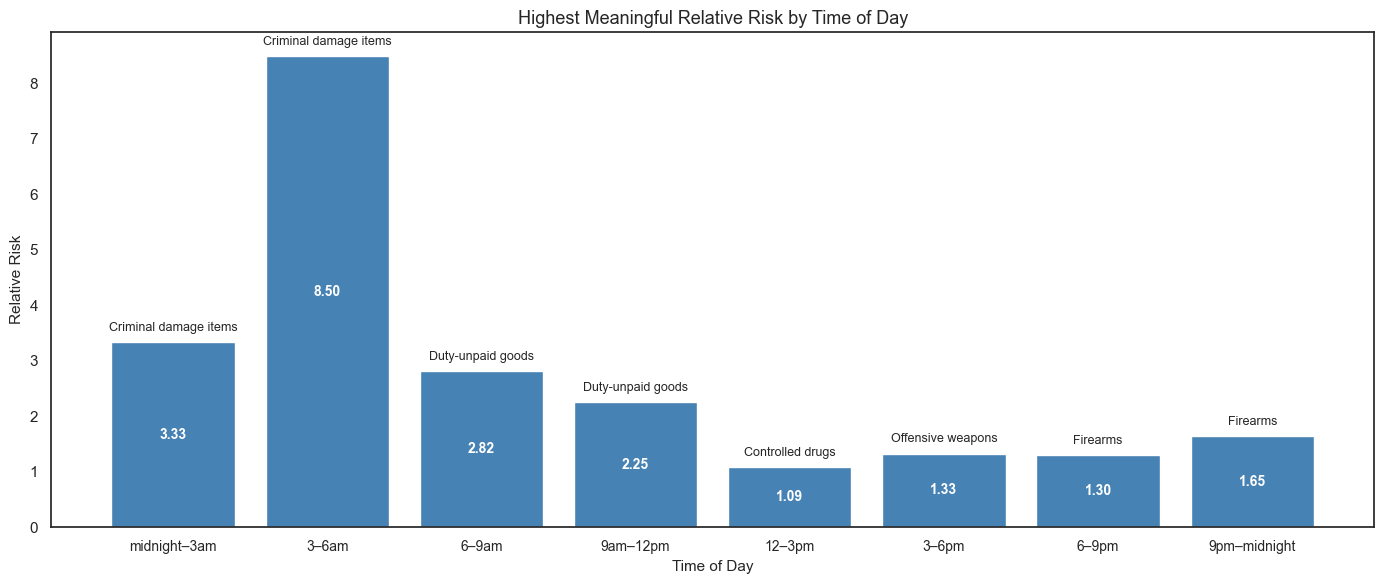

In [331]:

import matplotlib.pyplot as plt
import pandas as pd

# Data with friendly time labels
data = {
    'HourBin': [
        'midnight–3am',
        '3–6am',
        '6–9am',
        '9am–12pm',
        '12–3pm',
        '3–6pm',
        '6–9pm',
        '9pm–midnight'
    ],
    'RR': [3.334993, 8.497418, 2.815471, 2.252132, 1.086822, 1.326590, 1.303358, 1.647780],
    'RR_Group': [
        'Criminal damage items',
        'Criminal damage items',
        'Duty-unpaid goods',
        'Duty-unpaid goods',
        'Controlled drugs',
        'Offensive weapons',
        'Firearms',
        'Firearms'
    ]
}

df = pd.DataFrame(data)

plt.figure(figsize=(14,6))
bars = plt.bar(df['HourBin'], df['RR'], color='steelblue')

# Add RR values *inside* the bars
for bar, rr in zip(bars, df['RR']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height/2,
        f"{rr:.2f}",
        ha='center',
        va='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

# Add RR group labels *above* the bars
for bar, group in zip(bars, df['RR_Group']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        group,
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0
    )

# Time labels below bars (horizontal)
plt.xticks(
    ticks=range(len(df)),
    labels=df['HourBin'],
    rotation=0,
    fontsize=10
)

plt.xlabel('Time of Day')
plt.ylabel('Relative Risk')
plt.title('Highest Meaningful Relative Risk by Time of Day')

plt.tight_layout()
plt.show()



---
## 10. Predictive Modelling

| Section | Content |
|---|---|
| **A** | Imports |
| **B** | Data Preparation |
| **C** | Baseline Model (DummyClassifier) |
| **D** | Binary Logistic Regression |
| **E** | Multinomial Logistic Regression |
| **F** | SHAP Values |


---
## A. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import shap
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, average_precision_score
)

sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})
print('Imports OK')

---
## B. Data Preparation

All preparation before any model is fitted:
- **B1** Missing value audit & imputation
- **B2** Feature engineering & encoding
- **B3** VIF multicollinearity check
- **B4** Train / test split & class imbalance audit

In [ ]:
# ── B1. Missing value audit ───────────────────────────────────────────────────
df_prep = df_clean.copy()

FEATURES = ['Gender', 'Age range', 'Officer-defined ethnicity', 'Object of search', 'Date']
TARGETS  = ['Outcome linked to object of search', 'Outcome']

audit = df_prep[FEATURES + TARGETS].isnull().sum().rename('Missing').to_frame()
audit['% Missing'] = (audit['Missing'] / len(df_prep) * 100).round(2)
print(f'Total rows: {len(df_prep):,}\n')
print(audit.to_string())

In [ ]:
# ── B1 (cont). Imputation ─────────────────────────────────────────────────────
# Fill with explicit 'Unknown' rather than mode — missingness may carry signal.
for col in ['Gender', 'Age range', 'Officer-defined ethnicity', 'Object of search']:
    n = df_prep[col].isnull().sum()
    if n > 0:
        df_prep[col] = df_prep[col].fillna('Unknown')
        print(f'  {col}: {n:,} nulls → "Unknown"')

before = len(df_prep)
df_prep = df_prep.dropna(subset=TARGETS)
print(f'\nRows dropped (null targets only): {before - len(df_prep):,}')
print(f'Rows remaining: {len(df_prep):,}')

In [ ]:
# ── B2. Feature engineering & encoding ───────────────────────────────────────
df_prep['Date'] = pd.to_datetime(df_prep['Date'], utc=True)
df_prep['Hour'] = df_prep['Date'].dt.hour

# Binary target: True/False → 1/0
df_prep['outcome_binary'] = (
    df_prep['Outcome linked to object of search']
    .map({'True': 1, 'False': 0, True: 1, False: 0})
    .astype(int)
)

# Multi-class target: collapse rare categories (<1%) into 'Other'
freq = df_prep['Outcome'].value_counts(normalize=True)
rare = freq[freq < 0.01].index
df_prep['outcome_multi'] = df_prep['Outcome'].apply(
    lambda x: 'Other' if x in rare else x
)
print('Outcome classes (multi-class target):')
print(df_prep['outcome_multi'].value_counts())

# One-hot encode — drop_first avoids dummy variable trap
X_raw = pd.get_dummies(
    df_prep[['Gender', 'Age range', 'Officer-defined ethnicity', 'Object of search', 'Hour']],
    columns=['Gender', 'Age range', 'Officer-defined ethnicity', 'Object of search'],
    drop_first=True
).astype(float)

print(f'\nFeature matrix: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features')

In [ ]:
# ── B3. VIF multicollinearity check ──────────────────────────────────────────
# Computed on a 5k sample for speed. VIF > 10 = problematic.
X_vif  = sm.add_constant(X_raw.sample(5000, random_state=42))
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).set_index('Feature').drop('const')

flagged = vif_df[vif_df['VIF'] > 10]
print(f'Features with VIF > 10: {len(flagged)}')
print(flagged.sort_values('VIF', ascending=False).round(2).to_string() if len(flagged) else 'None ✓')

fig, ax = plt.subplots(figsize=(10, 6))
top_vif = vif_df.sort_values('VIF', ascending=False).head(20)
colors  = ['#e05c5c' if v > 10 else '#5c8ee0' if v > 5 else '#a8c8a8' for v in top_vif['VIF']]
ax.barh(top_vif.index[::-1], top_vif['VIF'][::-1], color=colors[::-1])
ax.axvline(10, color='red',    linestyle='--', linewidth=1, label='VIF = 10 (severe)')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1, label='VIF = 5 (moderate)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF — Top 20 Features', fontsize=12)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ── B4. Train / test split & class imbalance audit ───────────────────────────
y_bin   = df_prep['outcome_binary']
y_multi = df_prep['outcome_multi']

X_tr, X_te, y_tr_bin, y_te_bin = train_test_split(
    X_raw, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
_, _, y_tr_multi, y_te_multi = train_test_split(
    X_raw, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {len(X_tr):,}  |  Test: {len(X_te):,}')

# Class imbalance chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bin_counts = y_bin.value_counts().rename({0: 'Not Linked', 1: 'Linked'})
axes[0].bar(bin_counts.index, bin_counts.values, color=['#5c8ee0','#e05c5c'], edgecolor='white')
for i, v in enumerate(bin_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(y_bin)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Binary target')
axes[0].set_ylabel('Count')
sns.despine(ax=axes[0])

mc = y_multi.value_counts()
axes[1].barh(mc.index[::-1], mc.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Multi-class target')
axes[1].set_xlabel('Count')
sns.despine(ax=axes[1])

plt.suptitle('Class distribution  —  class_weight="balanced" applied to all models',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
print(f'Binary imbalance ratio: {bin_counts.max()/bin_counts.min():.1f}:1')

---
## C. Baseline Model

A `DummyClassifier` sets the performance floor before any real model is fitted.
Every subsequent model must beat this — if it doesn't, it has learned nothing useful.

In [ ]:
# ── C. Dummy classifier benchmark ────────────────────────────────────────────
dummy_rows = []
for strategy in ['most_frequent', 'stratified', 'uniform']:
    d   = DummyClassifier(strategy=strategy, random_state=42).fit(X_tr, y_tr_bin)
    yp  = d.predict(X_te)
    ypr = d.predict_proba(X_te)[:, 1]
    dummy_rows.append({
        'Model':    f'Dummy ({strategy})',
        'Accuracy': round((yp == y_te_bin).mean(), 4),
        'ROC-AUC':  round(roc_auc_score(y_te_bin, ypr), 4),
        'Avg Prec': round(average_precision_score(y_te_bin, ypr), 4),
    })

dummy_df = pd.DataFrame(dummy_rows).set_index('Model')
print('=== Dummy baseline performance ===')
print(dummy_df.to_string())

DUMMY_AUC = dummy_df['ROC-AUC'].max()
print(f'\nROC-AUC ceiling to beat: {DUMMY_AUC:.4f}')

---
## D. Binary Logistic Regression

**Target:** `Outcome linked to object of search` (1 = linked, 0 = not linked)

The scaler lives inside a Pipeline so it is re-fit on each CV fold — no data leakage.
We tune first, then evaluate the tuned model on the held-out test set.

In [ ]:
# ── D1. Tune via GridSearchCV (Pipeline = no leakage) ────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={
        'lr__C':       [0.001, 0.01, 0.1, 1, 10],
        'lr__penalty': ['l1', 'l2'],
        'lr__solver':  ['liblinear'],
    },
    cv=CV, scoring='roc_auc', n_jobs=-1
)
lr_grid.fit(X_tr, y_tr_bin)
lr_tuned = lr_grid.best_estimator_

print(f'Best params:     {lr_grid.best_params_}')
print(f'Best CV ROC-AUC: {lr_grid.best_score_:.4f}')

# Regularisation sensitivity
cv_res = pd.DataFrame(lr_grid.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
for pen, grp in cv_res.groupby('param_lr__penalty'):
    grp = grp.sort_values('param_lr__C')
    ax.semilogx(grp['param_lr__C'], grp['mean_test_score'],
                marker='o', label=f'penalty={pen}', linewidth=1.8)
    ax.fill_between(grp['param_lr__C'],
                    grp['mean_test_score'] - grp['std_test_score'],
                    grp['mean_test_score'] + grp['std_test_score'], alpha=0.12)
ax.axvline(lr_grid.best_params_['lr__C'], color='red', linestyle='--', linewidth=1,
           label=f'Best C={lr_grid.best_params_["lr__C"]}')
ax.set_xlabel('C  (lower = stronger regularisation)')
ax.set_ylabel('CV ROC-AUC')
ax.set_title('Binary LR — Regularisation sensitivity', fontsize=12)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ── D2. Evaluate tuned model on held-out test set ────────────────────────────
y_pred_lr = lr_tuned.predict(X_te)
y_prob_lr = lr_tuned.predict_proba(X_te)[:, 1]
auc_lr    = roc_auc_score(y_te_bin, y_prob_lr)

assert auc_lr > DUMMY_AUC, f'LR ({auc_lr:.4f}) does not beat dummy ({DUMMY_AUC:.4f})'

print('=== Classification Report — Tuned Binary LR ===')
print(classification_report(y_te_bin, y_pred_lr, target_names=['Not Linked', 'Linked']))
print(f'ROC-AUC:  {auc_lr:.4f}  (dummy ceiling: {DUMMY_AUC:.4f})')
print(f'Avg Prec: {average_precision_score(y_te_bin, y_prob_lr):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_te_bin, y_pred_lr), display_labels=['Not Linked', 'Linked']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Binary LR')

RocCurveDisplay.from_predictions(y_te_bin, y_prob_lr, ax=axes[1], color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Dummy')
axes[1].set_title('ROC Curve — Binary LR')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── D3. Odds ratios (statsmodels) ─────────────────────────────────────────────
# Re-scale training data using the best pipeline's scaler for sm.Logit.
scaler_d  = lr_tuned.named_steps['scaler']
X_tr_sc   = scaler_d.transform(X_tr)

# Inverse-frequency weights to replicate class_weight='balanced'
cc   = y_tr_bin.value_counts()
wmap = {c: len(y_tr_bin) / (2 * n) for c, n in cc.items()}
sw   = y_tr_bin.map(wmap).values

X_sm      = sm.add_constant(pd.DataFrame(X_tr_sc, columns=X_raw.columns))
logit_fit = sm.Logit(y_tr_bin.values, X_sm.values).fit(disp=False, freq_weights=sw)

coef_df = pd.DataFrame({
    'Odds Ratio': np.exp(logit_fit.params[1:]),
    'p-value':    logit_fit.pvalues[1:],
    'CI Lower':   np.exp(logit_fit.conf_int()[0][1:]),
    'CI Upper':   np.exp(logit_fit.conf_int()[1][1:]),
}, index=X_raw.columns).sort_values('Odds Ratio', ascending=False)

sig = coef_df[coef_df['p-value'] < 0.05]
print(f'Significant features (p<0.05): {len(sig)}')
print(sig.head(15).round(3).to_string())
print(f'\nPseudo R² (McFadden): {logit_fit.prsquared:.4f}')

# Forest plot
plot_df = sig.head(20).copy()
plot_df.index = (plot_df.index
    .str.replace('Object of search_', '', regex=False)
    .str.replace('Age range_', 'Age: ', regex=False)
    .str.replace('Officer-defined ethnicity_', '', regex=False)
    .str.replace('Gender_', '', regex=False))

fig, ax = plt.subplots(figsize=(10, 7))
ypos = range(len(plot_df))
ax.barh(list(ypos), plot_df['Odds Ratio'],
        color=['#e05c5c' if v > 1 else '#5c8ee0' for v in plot_df['Odds Ratio']], alpha=0.8)
ax.errorbar(plot_df['Odds Ratio'], list(ypos),
            xerr=[plot_df['Odds Ratio'] - plot_df['CI Lower'],
                  plot_df['CI Upper']   - plot_df['Odds Ratio']],
            fmt='none', color='black', capsize=3, linewidth=1)
ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Odds Ratio (95% CI) — standardised features')
ax.set_title('Significant Predictors — Binary LR (p < 0.05)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

---
## E. Multinomial Logistic Regression

**Target:** `outcome_multi` — full outcome category (rare classes collapsed to 'Other')

Same structure as Section D: tune → evaluate → interpret.

In [ ]:
# ── E1. Tune via GridSearchCV ─────────────────────────────────────────────────
mlr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                  max_iter=1000, class_weight='balanced', random_state=42)),
])

mlr_grid = GridSearchCV(
    mlr_pipe,
    param_grid={'lr__C': [0.01, 0.1, 1, 10]},
    cv=CV, scoring='f1_macro', n_jobs=-1
)
mlr_grid.fit(X_tr, y_tr_multi)
mlr_tuned = mlr_grid.best_estimator_

print(f'Best params:      {mlr_grid.best_params_}')
print(f'Best CV F1-macro: {mlr_grid.best_score_:.4f}')

In [ ]:
# ── E2. Evaluate on held-out test set ─────────────────────────────────────────
y_pred_multi = mlr_tuned.predict(X_te)

print('=== Classification Report — Tuned Multinomial LR ===')
print(classification_report(y_te_multi, y_pred_multi, zero_division=0))

# Normalised confusion matrix
labels = sorted(y_multi.unique())
cm_m   = confusion_matrix(y_te_multi, y_pred_multi, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm_m, index=labels, columns=labels),
            annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Normalised Confusion Matrix — Tuned Multinomial LR', fontsize=12)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── E3. Coefficient heatmap (feature × outcome class) ─────────────────────────
lr_step   = mlr_tuned.named_steps['lr']
coef_mat  = pd.DataFrame(lr_step.coef_, index=lr_step.classes_, columns=X_raw.columns)
top_feats = coef_mat.abs().max(axis=0).nlargest(15).index
coef_top  = coef_mat[top_feats].copy()
coef_top.columns = (coef_top.columns
    .str.replace('Object of search_', '', regex=False)
    .str.replace('Age range_', 'Age: ', regex=False)
    .str.replace('Officer-defined ethnicity_', '', regex=False)
    .str.replace('Gender_', '', regex=False))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_top, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('Multinomial LR — Coefficients by Outcome Class (top 15 features)', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## F. SHAP Values

SHAP explains individual predictions from the binary LR — showing not just which features
matter globally, but the direction and magnitude of each feature's contribution to each
specific prediction.

We use `LinearExplainer` (appropriate for logistic regression) on a 1,000-row test sample.

In [ ]:
# ── F1. Compute SHAP values ───────────────────────────────────────────────────
# Extract the fitted scaler from the pipeline and transform the sample
scaler_f  = lr_tuned.named_steps['scaler']
X_te_sc   = scaler_f.transform(X_te)
X_shap_sc = pd.DataFrame(X_te_sc, columns=X_raw.columns).sample(1000, random_state=42)

explainer = shap.LinearExplainer(
    lr_tuned.named_steps['lr'],
    X_shap_sc,
    feature_perturbation='interventional'
)
shap_vals = explainer.shap_values(X_shap_sc)

feat_names = (
    pd.Index(X_raw.columns)
    .str.replace('Object of search_', '', regex=False)
    .str.replace('Age range_', 'Age: ', regex=False)
    .str.replace('Officer-defined ethnicity_', '', regex=False)
    .str.replace('Gender_', '', regex=False)
    .tolist()
)
print(f'SHAP values computed — shape: {shap_vals.shape}')

In [ ]:
# ── F2. Beeswarm plot ─────────────────────────────────────────────────────────
# Each dot = 1 prediction. x = SHAP value (push toward linked=1 or linked=0).
# Colour = feature value (red = high, blue = low).
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap_sc.values,
                  feature_names=feat_names, max_display=15, show=False)
plt.title('SHAP Beeswarm — Binary LR\n'
          '(dot = 1 prediction  |  colour = feature value  |  x = impact on prediction)',
          fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── F3. Global importance bar chart (mean |SHAP|) ─────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap_sc.values,
                  feature_names=feat_names, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Global Importance — Binary LR  (mean |SHAP value|)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 11. Summary & Conclusions


### Conlusion Summary to date
#### Controlled drugs is the dominant serah overall -31.42% happen betwen 3pm-6pm
